In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time
from sklearn.linear_model import LogisticRegression
import collections
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Credit Card Fraud Detection Dataset

In [3]:
df_row = pd.read_csv('/content/drive/My Drive/creditcard.csv')

In [7]:
df = df_row
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


### Random Under-Sampling:

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

X = df.drop('Class', axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# We already have X_train and y_train for undersample data thats why I am using original to distinguish and to not overwrite these variables.
# original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the Distribution of the labels


# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset
Train: [ 30473  30496  31002 ... 284804 284805 284806] Test: [    0     1     2 ... 57017 57018 57019]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 30473  30496  31002 ... 113964 113965 113966]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 81609  82400  83053 ... 170946 170947 170948]
Train: [     0      1      2 ... 284804 284805 284806] Test: [150654 150660 150661 ... 227866 227867 227868]
Train: [     0      1      2 ... 227866 227867 227868] Test: [212516 212644 213092 ... 284804 284805 284806]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]


In [10]:
df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
240876,150790.0,1.863903,-0.475438,-1.066490,0.338899,-0.355357,-1.032911,0.192039,-0.333468,0.999591,...,-0.103231,-0.216380,0.129007,0.080667,-0.081076,-0.102965,-0.038180,-0.038490,97.01,0
150715,93965.0,-11.397727,7.763953,-18.572307,6.711855,-10.174216,-4.395918,-15.893788,2.083013,-4.988837,...,0.339007,1.342923,0.239217,0.534644,-0.174965,-0.500240,-1.722060,-0.574339,11.40,1
139064,82990.0,1.108580,-0.056391,0.283986,0.628215,-0.570244,-0.874978,0.061247,-0.076441,-0.106818,...,0.085185,0.070170,-0.087347,0.548827,0.415365,0.365208,-0.062217,0.008545,58.85,0
262826,160665.0,-0.417340,4.700055,-7.521767,7.671884,0.260821,-2.646693,-2.854432,0.958783,-4.588536,...,0.622200,-0.437708,-0.090358,-0.742802,-0.312361,0.502575,0.821390,0.372379,0.77,1
190368,128803.0,-2.272473,2.935226,-4.871394,2.419012,-1.513022,-0.480625,-2.126136,1.883507,-1.297262,...,0.718504,0.893850,-0.031632,0.322913,-0.058406,-0.411649,0.573803,0.176067,175.90,1


In [13]:
print('Distribution of the Classes in the subsample dataset')
print(new_df['Class'].value_counts()/len(new_df))

Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


### Baseline Model

In [14]:
# Undersampling before cross validating (prone to overfit)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [15]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [17]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
}

In [18]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 94.0 % accuracy score


In [19]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

In [20]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  94.28%


In [201]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict



log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")


precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)
undersample_y_score = log_reg.decision_function(original_Xtest)


undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.96


## CSM Model

In [39]:
from scipy.stats import spearmanr
correlacoes_p = []
correlacoes_s = []
variaveis = X.columns
for COLUNA in X:
  correlacoes_p.append(np.round(y.corr(X[COLUNA]),2))
  correlacao, p = spearmanr(y, X[COLUNA])
  correlacoes_s.append(np.round(correlacao,2))
df_cor = pd.DataFrame({'Variaveis': variaveis, 'Correlacoes_S': correlacoes_s, 'Correlacoes_P': correlacoes_p})

In [41]:
df_cor = df_cor.dropna()
df_cor['fx']= pd.qcut(df_cor['Correlacoes_P'], q=4)

lista_variaveis_fx = []
for i in list((range(0,len(pd.unique(df_cor['fx']))))):
  lista_variaveis_fx.append(df_cor[df_cor['fx']==pd.unique(df_cor['fx'])[i]].Variaveis)


tamanho_dos_grupos=[]
lista_de_grupos=[]
lista_variaveis_fx[0]
for i in list(range(0,len(lista_variaveis_fx))):
  lista_de_grupos.append('Grupo '+str(i))
  tamanho_dos_grupos.append(len(lista_variaveis_fx[i]))

divisao_grupos = pd.DataFrame({'Grupos':lista_de_grupos,'Tamanho do Grupo':tamanho_dos_grupos})

In [45]:
divisao_grupos

,Grupos,Tamanho do Grupo
0,Grupo 0,4
1,Grupo 1,24


In [166]:
from functools import reduce
from more_itertools import interleave

X_vetor = []
X_vetor_train = []
X_vetor_test = []
y_vetor_train = []
y_vetor_test = []
for i in list(range(0,len(lista_variaveis_fx))):
  X_vetor.append('X_'+str(i+1))
  X_vetor_train.append('X_train_'+str(i+1))
  X_vetor_test.append('X_test_'+str(i+1))
  y_vetor_train.append('y_train_'+str(i+1))
  y_vetor_test.append('y_test_'+str(i+1))

for i in list(range(0,len(lista_variaveis_fx))):
  X_vetor[i] = X[lista_variaveis_fx[i]]
  X_vetor_train[i], X_vetor_test[i],y_vetor_train[i], y_vetor_test[i]= train_test_split(X_vetor[i], y, test_size = 0.3)


n = int(X_vetor[0].shape[0]/12)
a = list(range(1,13))
resto = safra[0]
safra_1 = list(interleave(*[a]*n))
n_resto =  abs(X_vetor[0].shape[0] - len(safra_1))
safra_2 =pd.Series(resto).repeat(n_resto).tolist()
safra = safra_1 + safra_2

retorno_grupo = []
for i in list(range(0,len(X_vetor))):
  df_x = X_vetor[i]
  df_x['safra']= safra
  df_x['target']= y
  clf = LogisticRegression()
  retorno_safra = []
  id_safra = []
  for ANO in pd.unique(df_x['safra']):
    df_xx = df_x[df_x['safra']==ANO]
    x_filtrado = df_xx.drop(['safra','target'], axis = 1)
    y_filtrado = df_xx.target
    x_filtrado_train, x_filtrado_test, y_filtrado_train, y_filtrado_test= train_test_split(x_filtrado, y_filtrado, test_size = 0.3)
    clf.fit(x_filtrado_train, y_filtrado_train)
    pred_filtrado =clf.predict(x_filtrado_test)
    retorno_safra.append(accuracy_score(pred_filtrado, y_filtrado_test))
    id_safra.append(ANO)
  df_retornos = pd.DataFrame({'Retorno Grupo '+str(i): retorno_safra, 'Safra': id_safra})
  retorno_grupo.append(df_retornos)
df_retornos = reduce(lambda  left,right: pd.merge(left,right,on=['Safra'],how='outer'), retorno_grupo)


In [168]:
df_retornos[['Safra','Retorno Grupo 0','Retorno Grupo 1']]

,Safra,Retorno Grupo 0,Retorno Grupo 1
0,1,0.76,0.80
1,2,0.84,1.00
2,3,0.76,0.84
3,4,0.88,0.96
4,5,0.88,0.92
5,6,0.84,0.92
6,7,0.68,0.84
7,8,0.76,0.92
8,9,0.80,0.92
9,10,0.80,1.00


In [169]:
#Cálculo do retorno do portifolio
def get_portfolio_returns(returns, weights):
    return np.dot(returns.mean(), weights)
#Cálculo do risco do portifólio, considerando o desvio padrão
def get_portfolio_risk(returns, weights):
    covariances = returns.cov()
    var_risk = np.matmul(np.matmul((weights), covariances.values), weights)
    std_risk = np.sqrt(var_risk)
    return std_risk
def mount_portfolio(x , args):
    return get_portfolio_risk(args, x)
def compute_frontier(returns_range, returns_df):
    optimal_portfolios = []
    #restrição para que a soma dos pesos não ultrapasse o valor 1
    eq_constraint_proportions = {'type': 'eq', 'fun': lambda x: sum(x) - 1}
    #definição dos limites inferior e superior dos pesos em 0 e 1, respectivamente
    bounds = Bounds(ub=[1,1,1,1], lb=[0,0,0,0])


    #ponto de paprtida para o algoritmo de otimização, foram utilizados pesos igualmente distribuídos
    initial_guess = np.ones(len(returns_df.columns))*1/len(returns_df.columns)
    for value in returns_range:
        #restrição para garantir que o valor de retorno desejado será mantido
        eq_constraint_return = {'type':'eq', 'fun': lambda x : get_portfolio_returns(returns_df, x) - value}

        optimal_weights = minimize(mount_portfolio, x0 = initial_guess, method = 'SLSQP',
                constraints = [eq_constraint_proportions, eq_constraint_return],
                bounds=bounds,  options={'ftol':1e-9, 'disp':False},
                args = (returns_df,))
        optimal_portfolios.append(optimal_weights)

    return optimal_portfolios

In [170]:
#Definição dos patamares de retorno máximo e mínimo
real_returns = df_retornos.drop(['Safra'],axis=1)
min_return = real_returns.mean().min()
max_return = real_returns.mean().max()
def generate_random_portfolios(num_samples, returns):
    returns_from_random_weights = []
    risks_from_random_weights = []
    weights = []
    for i in range(0, num_samples):
        random_weights = np.random.rand(len(returns.columns))
        random_weights = random_weights/np.sum(random_weights)
        weights.append(random_weights)

        random_return = get_portfolio_returns(returns, random_weights)
        random_risk = get_portfolio_risk(returns, random_weights)

        returns_from_random_weights.append(random_return)
        risks_from_random_weights.append(random_risk)
    return [risks_from_random_weights, returns_from_random_weights, weights]


Text(0.5, 0, 'Risco')

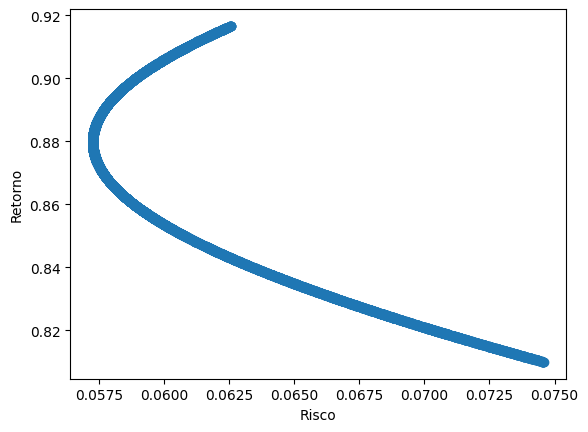

In [171]:

random_ports = generate_random_portfolios(10000, real_returns)
plt.scatter(random_ports[0], random_ports[1])
plt.ylabel('Retorno')
plt.xlabel('Risco')


In [172]:

fronteira_eficiente = pd.DataFrame({'Risco':random_ports[0],'Retorno':random_ports[1], 'Pesos':random_ports[2]})
fronteira_eficiente['Pesos'] = fronteira_eficiente.Pesos.apply(lambda x: np.round(x, 2))

In [173]:
alocacao_otima = fronteira_eficiente[fronteira_eficiente.Risco ==fronteira_eficiente.Risco.min()]
alocacao_otima[['Risco','Retorno']]


,Risco,Retorno
7378,0.05726,0.87982


In [174]:

alocacao_otima.Pesos

,Pesos
7378,"[0.35, 0.65]"


In [175]:
divisao_grupos['Alocacao Otima'] = alocacao_otima.Pesos.values[0]
divisao_grupos['Tamanho Final do Grupo'] = round((divisao_grupos['Tamanho do Grupo']*divisao_grupos['Alocacao Otima'])/divisao_grupos['Alocacao Otima'].sum(),0)
divisao_grupos

,Grupos,Tamanho do Grupo,Alocacao Otima,Tamanho Final do Grupo
0,Grupo 0,4,0.35,1.0
1,Grupo 1,24,0.65,16.0


In [176]:
variaveis_filtradas_csm = []
for i in list(range(0,len(X_vetor))):
  df_x = X_vetor[i]
  df_x = df_x.drop(['safra','target'],axis=1,errors='ignore')
  df_x = df_x.sample(n=int(divisao_grupos['Tamanho Final do Grupo'][i]),axis='columns')
  #df_x = df_x.sample(n=math.ceil(divisao_grupos['Alocacao Otima'][i]*df_x.shape[1]),axis='columns')
  variaveis_filtradas_csm.extend(df_x.columns)

In [186]:
print("Restaram" , len(variaveis_filtradas_csm), "features.", " Foram elas:", variaveis_filtradas_csm)

Restaram 17 features.  Foram elas: ['V16', 'V28', 'V17', 'V3', 'V11', 'V19', 'V22', 'V23', 'V7', 'V12', 'V21', 'V26', 'V10', 'V18', 'V9', 'V8', 'V6']


In [197]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict




# Undersampling before cross validating (prone to overfit)
X = new_df[variaveis_filtradas_csm]
y = new_df['Class']


sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]



# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
}


# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_


# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)





Train: [195 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250
 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268
 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286
 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304
 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322
 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339 340
 341 342 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357 358
 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375 376
 377 378 379 380 381 382 383 384 385 386 387 388 389 390 391 392 393 394
 395 396 397 398 399 400 401 402 403 404 405 406 407 408 409 410 411 412
 413 414 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 430
 431 432 433 434 435 436 437 438 439 440 441

In [196]:
original_Xtest[0]

array([ 1.38894000e+05, -1.29844323e+00,  1.94810045e+00, -4.50994689e+00,
        1.30580477e+00, -1.94859272e-02, -5.09237784e-01, -2.64339762e+00,
        1.28354519e+00, -2.51535570e+00, -4.50131481e+00,  2.09307501e+00,
       -5.41888894e+00, -1.24701371e+00, -3.82826818e+00,  3.99050337e-01,
       -6.36649951e+00, -7.55096809e+00, -4.90276667e+00,  1.52892032e-01,
        2.50415437e-01,  1.17803195e+00,  1.36098858e+00, -2.72013060e-01,
       -3.25947896e-01,  2.90702673e-01,  8.41294588e-01,  6.43094249e-01,
        2.01155750e-01,  1.00000000e-02])

In [199]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict



log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")


precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)
undersample_y_score = log_reg.decision_function(original_Xtest)


undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)


In [203]:
print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.94


# Financial Fraud Detection Dataset

In [239]:
df_row = pd.read_csv('/content/drive/My Drive/Synthetic_Financial_datasets_log.csv')

In [240]:
df = df_row
df['type'] = df['type'].astype('category').cat.codes
df['nameOrig'] = df['nameOrig'].astype('category').cat.codes
df['nameDest'] = df['nameDest'].astype('category').cat.codes
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,757869,170136.0,160296.36,1662094,0.0,0.0,0,0
1,1,3,1864.28,2188998,21249.0,19384.72,1733924,0.0,0.0,0,0
2,1,4,181.00,1002156,181.0,0.00,439685,0.0,0.0,1,0
3,1,1,181.00,5828262,181.0,0.00,391696,21182.0,0.0,1,0
4,1,3,11668.14,3445981,41554.0,29885.86,828919,0.0,0.0,0,0


In [241]:
print('No Frauds', round(df['isFraud'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['isFraud'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.87 % of the dataset
Frauds 0.13 % of the dataset


### Random Under-Sampling:

In [242]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

X = df.drop('isFraud', axis=1)
y = df['isFraud']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# We already have X_train and y_train for undersample data thats why I am using original to distinguish and to not overwrite these variables.
# original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the Distribution of the labels


# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

Train: [1272422 1272423 1272424 ... 6362617 6362618 6362619] Test: [      0       1       2 ... 1510291 1510292 1510293]
Train: [      0       1       2 ... 6362617 6362618 6362619] Test: [1272422 1272423 1272424 ... 3958614 3958615 3958622]
Train: [      0       1       2 ... 6362617 6362618 6362619] Test: [2544062 2544063 2544064 ... 6009078 6009346 6009347]
Train: [      0       1       2 ... 6362617 6362618 6362619] Test: [3815834 3815835 3815836 ... 6243165 6243166 6243645]
Train: [      0       1       2 ... 6243165 6243166 6243645] Test: [5087485 5087486 5087487 ... 6362617 6362618 6362619]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99870926 0.00129074]
[0.99870887 0.00129113]


In [243]:
df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['isFraud'] == 1]
non_fraud_df = df.loc[df['isFraud'] == 0][:8213]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)
new_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1225208,133,3,16229.01,2953270,21215.00,4985.99,2504495,0.00,0.0,0,0
2599237,208,1,223958.35,1676293,0.00,0.00,447998,241325.35,465283.7,0,0
6362542,737,4,946705.53,1721465,946705.53,0.00,382226,0.00,0.0,1,0
2246689,186,4,345802.34,293561,345802.34,0.00,497286,0.00,0.0,1,0
2678995,210,1,94431.98,5122501,94431.98,0.00,510745,253005.72,347437.7,1,0


In [244]:
print('Distribution of the Classes in the subsample dataset')
print(new_df['isFraud'].value_counts()/len(new_df))

Distribution of the Classes in the subsample dataset
isFraud
0    0.5
1    0.5
Name: count, dtype: float64


### Baseline Model

In [245]:
# Undersampling before cross validating (prone to overfit)
X = new_df.drop('isFraud', axis=1)
y = new_df['isFraud']

In [246]:
X

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
1225208,133,3,16229.01,2953270,21215.00,4985.99,2504495,0.00,0.00,0
2599237,208,1,223958.35,1676293,0.00,0.00,447998,241325.35,465283.70,0
6362542,737,4,946705.53,1721465,946705.53,0.00,382226,0.00,0.00,0
2246689,186,4,345802.34,293561,345802.34,0.00,497286,0.00,0.00,0
2678995,210,1,94431.98,5122501,94431.98,0.00,510745,253005.72,347437.70,0
...,...,...,...,...,...,...,...,...,...,...
3529602,259,1,455334.85,4292565,0.00,0.00,230545,7919562.60,8374897.45,0
3576963,261,0,275420.90,1742010,21410.00,296830.90,495796,0.00,0.00,0
4589636,328,4,337810.17,1966752,337810.17,0.00,24197,0.00,0.00,0
6063981,503,4,854065.31,4966164,854065.31,0.00,150466,0.00,0.00,0


In [247]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [248]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [249]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
}

In [250]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 94.0 % accuracy score


In [251]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

In [252]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  93.93%


In [326]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict



log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")


precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)
undersample_y_score = log_reg.decision_function(original_Xtest)


undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.86


## CSM Model

In [254]:
from scipy.stats import spearmanr
correlacoes_p = []
correlacoes_s = []
variaveis = X.columns
for COLUNA in X:
  correlacoes_p.append(np.round(y.corr(X[COLUNA]),2))
  correlacao, p = spearmanr(y, X[COLUNA])
  correlacoes_s.append(np.round(correlacao,2))
df_cor = pd.DataFrame({'Variaveis': variaveis, 'Correlacoes_S': correlacoes_s, 'Correlacoes_P': correlacoes_p})

In [258]:
df_cor = df_cor.dropna()
df_cor['fx']= pd.qcut(df_cor['Correlacoes_P'], q=4)

lista_variaveis_fx = []
for i in list((range(0,len(pd.unique(df_cor['fx']))))):
  lista_variaveis_fx.append(df_cor[df_cor['fx']==pd.unique(df_cor['fx'])[i]].Variaveis)


tamanho_dos_grupos=[]
lista_de_grupos=[]
lista_variaveis_fx[0]
for i in list(range(0,len(lista_variaveis_fx))):
  lista_de_grupos.append('Grupo '+str(i))
  tamanho_dos_grupos.append(len(lista_variaveis_fx[i]))

divisao_grupos = pd.DataFrame({'Grupos':lista_de_grupos,'Tamanho do Grupo':tamanho_dos_grupos})

In [261]:
divisao_grupos

,Grupos,Tamanho do Grupo
0,Grupo 0,2
1,Grupo 1,8


In [262]:
from functools import reduce
from more_itertools import interleave

X_vetor = []
X_vetor_train = []
X_vetor_test = []
y_vetor_train = []
y_vetor_test = []
for i in list(range(0,len(lista_variaveis_fx))):
  X_vetor.append('X_'+str(i+1))
  X_vetor_train.append('X_train_'+str(i+1))
  X_vetor_test.append('X_test_'+str(i+1))
  y_vetor_train.append('y_train_'+str(i+1))
  y_vetor_test.append('y_test_'+str(i+1))

for i in list(range(0,len(lista_variaveis_fx))):
  X_vetor[i] = X[lista_variaveis_fx[i]]
  X_vetor_train[i], X_vetor_test[i],y_vetor_train[i], y_vetor_test[i]= train_test_split(X_vetor[i], y, test_size = 0.3)


n = int(X_vetor[0].shape[0]/12)
a = list(range(1,13))
resto = safra[0]
safra_1 = list(interleave(*[a]*n))
n_resto =  abs(X_vetor[0].shape[0] - len(safra_1))
safra_2 =pd.Series(resto).repeat(n_resto).tolist()
safra = safra_1 + safra_2

retorno_grupo = []
for i in list(range(0,len(X_vetor))):
  df_x = X_vetor[i]
  df_x['safra']= safra
  df_x['target']= y
  clf = LogisticRegression()
  retorno_safra = []
  id_safra = []
  for ANO in pd.unique(df_x['safra']):
    df_xx = df_x[df_x['safra']==ANO]
    x_filtrado = df_xx.drop(['safra','target'], axis = 1)
    y_filtrado = df_xx.target
    x_filtrado_train, x_filtrado_test, y_filtrado_train, y_filtrado_test= train_test_split(x_filtrado, y_filtrado, test_size = 0.3)
    clf.fit(x_filtrado_train, y_filtrado_train)
    pred_filtrado =clf.predict(x_filtrado_test)
    retorno_safra.append(accuracy_score(pred_filtrado, y_filtrado_test))
    id_safra.append(ANO)
  df_retornos = pd.DataFrame({'Retorno Grupo '+str(i): retorno_safra, 'Safra': id_safra})
  retorno_grupo.append(df_retornos)
df_retornos = reduce(lambda  left,right: pd.merge(left,right,on=['Safra'],how='outer'), retorno_grupo)


In [263]:
df_retornos[['Safra','Retorno Grupo 0','Retorno Grupo 1']]

,Safra,Retorno Grupo 0,Retorno Grupo 1
0,1,0.787440,0.548309
1,2,0.754258,0.472019
2,3,0.798054,0.535280
3,4,0.810219,0.474453
4,5,0.783455,0.491484
5,6,0.705596,0.459854
6,7,0.778589,0.508516
7,8,0.795620,0.515815
8,9,0.781022,0.503650
9,10,0.639903,0.510949


In [264]:
#Cálculo do retorno do portifolio
def get_portfolio_returns(returns, weights):
    return np.dot(returns.mean(), weights)
#Cálculo do risco do portifólio, considerando o desvio padrão
def get_portfolio_risk(returns, weights):
    covariances = returns.cov()
    var_risk = np.matmul(np.matmul((weights), covariances.values), weights)
    std_risk = np.sqrt(var_risk)
    return std_risk
def mount_portfolio(x , args):
    return get_portfolio_risk(args, x)
def compute_frontier(returns_range, returns_df):
    optimal_portfolios = []
    #restrição para que a soma dos pesos não ultrapasse o valor 1
    eq_constraint_proportions = {'type': 'eq', 'fun': lambda x: sum(x) - 1}
    #definição dos limites inferior e superior dos pesos em 0 e 1, respectivamente
    bounds = Bounds(ub=[1,1,1,1], lb=[0,0,0,0])


    #ponto de paprtida para o algoritmo de otimização, foram utilizados pesos igualmente distribuídos
    initial_guess = np.ones(len(returns_df.columns))*1/len(returns_df.columns)
    for value in returns_range:
        #restrição para garantir que o valor de retorno desejado será mantido
        eq_constraint_return = {'type':'eq', 'fun': lambda x : get_portfolio_returns(returns_df, x) - value}

        optimal_weights = minimize(mount_portfolio, x0 = initial_guess, method = 'SLSQP',
                constraints = [eq_constraint_proportions, eq_constraint_return],
                bounds=bounds,  options={'ftol':1e-9, 'disp':False},
                args = (returns_df,))
        optimal_portfolios.append(optimal_weights)

    return optimal_portfolios

In [265]:
#Definição dos patamares de retorno máximo e mínimo
real_returns = df_retornos.drop(['Safra'],axis=1)
min_return = real_returns.mean().min()
max_return = real_returns.mean().max()
def generate_random_portfolios(num_samples, returns):
    returns_from_random_weights = []
    risks_from_random_weights = []
    weights = []
    for i in range(0, num_samples):
        random_weights = np.random.rand(len(returns.columns))
        random_weights = random_weights/np.sum(random_weights)
        weights.append(random_weights)

        random_return = get_portfolio_returns(returns, random_weights)
        random_risk = get_portfolio_risk(returns, random_weights)

        returns_from_random_weights.append(random_return)
        risks_from_random_weights.append(random_risk)
    return [risks_from_random_weights, returns_from_random_weights, weights]


Text(0.5, 0, 'Risco')

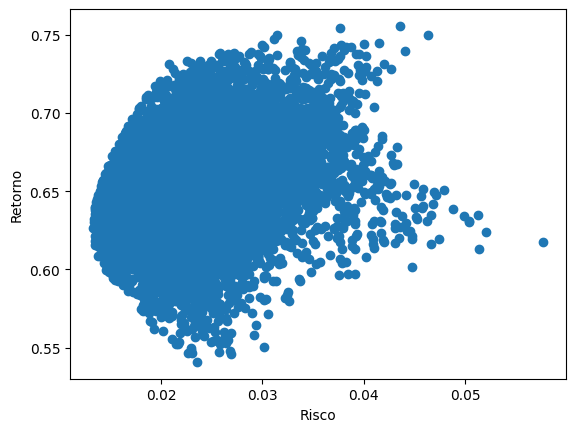

In [266]:

random_ports = generate_random_portfolios(10000, real_returns)
plt.scatter(random_ports[0], random_ports[1])
plt.ylabel('Retorno')
plt.xlabel('Risco')


In [267]:

fronteira_eficiente = pd.DataFrame({'Risco':random_ports[0],'Retorno':random_ports[1], 'Pesos':random_ports[2]})
fronteira_eficiente['Pesos'] = fronteira_eficiente.Pesos.apply(lambda x: np.round(x, 2))

In [268]:
alocacao_otima = fronteira_eficiente[fronteira_eficiente.Risco ==fronteira_eficiente.Risco.min()]
alocacao_otima[['Risco','Retorno']]


,Risco,Retorno
5828,0.013261,0.626546


In [297]:

alocacao_otima.Pesos


,Pesos
5828,"[0.11, 0.89]"


In [302]:
divisao_grupos['Alocacao Otima'] = alocacao_otima.Pesos.values[0]
divisao_grupos['Tamanho Final do Grupo'] = round((divisao_grupos['Tamanho do Grupo']*divisao_grupos['Alocacao Otima'])/divisao_grupos['Alocacao Otima'].sum(),0)

In [303]:
divisao_grupos

,Grupos,Tamanho do Grupo,Alocacao Otima,Tamanho Final do Grupo
0,Grupo 0,2,0.11,0.0
1,Grupo 1,8,0.89,7.0


In [315]:
features_elegiveis = new_df.drop(['nameOrig','newbalanceOrig','isFraud'], axis=1)

In [319]:
variaveis_filtradas_csm = features_elegiveis.sample(n=7,axis='columns')

In [321]:
print("Restaram" , len(variaveis_filtradas_csm), "features.", " Foram elas:", variaveis_filtradas_csm.columns.values)

Restaram 16426 features.  Foram elas: ['oldbalanceDest' 'newbalanceDest' 'type' 'step' 'isFlaggedFraud'
 'nameDest' 'oldbalanceOrg']


In [322]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict




# Undersampling before cross validating (prone to overfit)
X = variaveis_filtradas_csm
y = new_df.isFraud


sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]



# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
}


# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_


# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)





Train: [ 3272  3274  3276 ... 16423 16424 16425] Test: [   0    1    2 ... 3295 3296 3297]
Train: [    0     1     2 ... 16423 16424 16425] Test: [3272 3274 3276 ... 6614 6615 6616]
Train: [    0     1     2 ... 16423 16424 16425] Test: [6523 6524 6526 ... 9875 9876 9879]
Train: [    0     1     2 ... 16423 16424 16425] Test: [ 9835  9836  9838 ... 13146 13147 13149]
Train: [    0     1     2 ... 13146 13147 13149] Test: [13133 13136 13140 ... 16423 16424 16425]
Classifiers:  LogisticRegression Has a training score of 80.0 % accuracy score


In [324]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict



log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")


precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)
undersample_y_score = log_reg.decision_function(original_Xtest)


undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)


In [328]:
print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.81
